# Chart Spec Visual Test

Dummy data per chart type -> validate through `GenerateChartArgs` (exercises the real
discriminated union, same as the real tool receives) -> render -> display, so each
chart can be looked at directly rather than just checked for "didn't crash"
(`docs/chart-tool.md`).

In [1]:
import io
import sys
sys.path.insert(0, "..")

import pandas as pd
from IPython.display import display, Image

from app.mcp_server.chart_tool import (
    GenerateChartArgs,
    BarChartSpec, HorizontalBarChartSpec, GroupedBarChartSpec,
    StackedHorizontalBarChartSpec, LineChartSpec, HistogramChartSpec,
    BoxChartSpec, HeatmapChartSpec, ConcentrationChartSpec, ParetoChartSpec,
)


def validate_and_render(data: list[dict], spec: dict, expected_cls: type) -> None:
    """Validates through the same GenerateChartArgs the real tool uses, confirms
    the discriminator dispatched to the expected class, renders, and displays as a
    real PNG -- fig alone won't show inline under the Agg backend chart_tool.py
    forces at import (needed for headless Cloud Run)."""
    args = GenerateChartArgs.model_validate({"data": data, "spec": spec})
    assert isinstance(args.spec, expected_cls), f"Expected {expected_cls.__name__}, got {type(args.spec).__name__}"
    print(f"Validated as {type(args.spec).__name__}")
    fig = args.spec.render(pd.DataFrame(args.data))
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    display(Image(data=buf.getvalue()))


c:\Users\jmhla\projects\analytics-agent\.venv\Lib\site-packages\fastmcp\tools\base.py:281: FastMCPDeprecationWarning: The `exclude_args` parameter is deprecated as of FastMCP 2.14. Use dependency injection with `Depends()` instead for better lifecycle management. See https://gofastmcp.com/servers/dependency-injection#using-depends for examples.
  return FunctionTool.from_function(


## `bar`

Validated as BarChartSpec


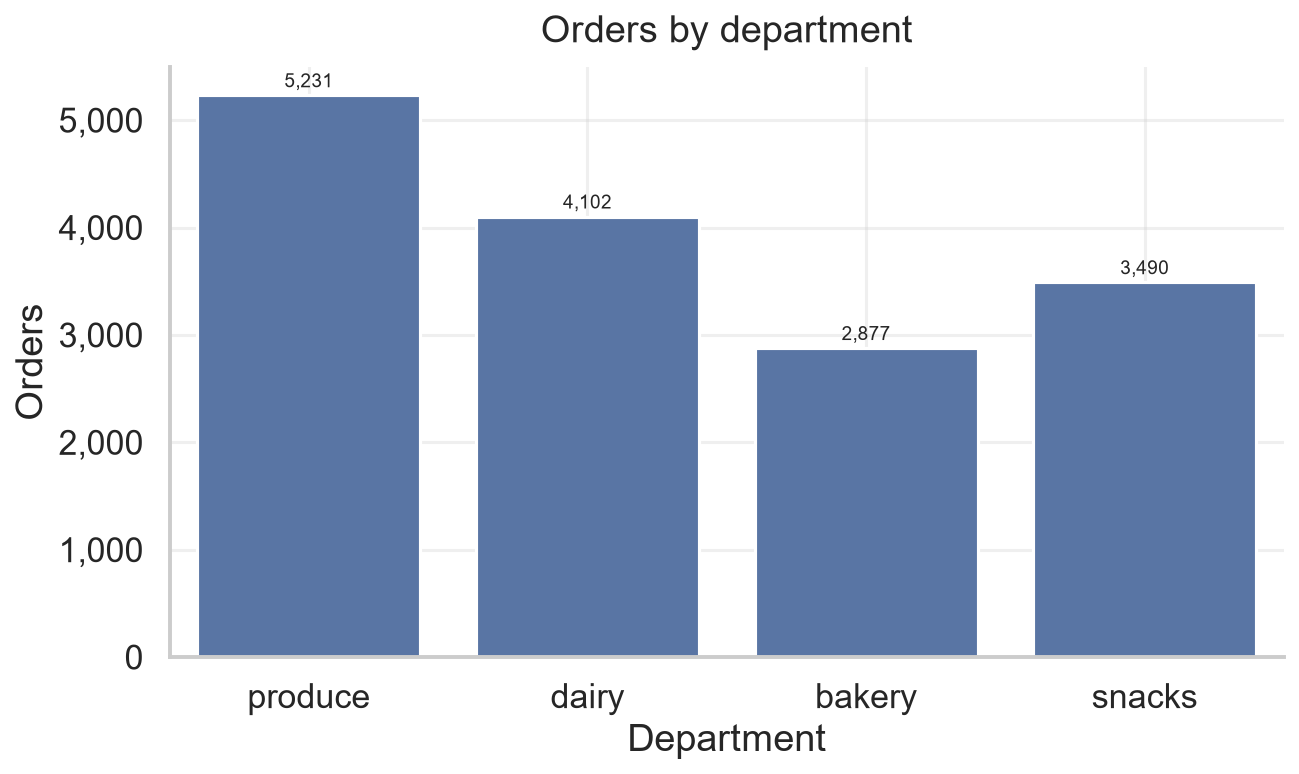

In [2]:
data = [
    {"department": "produce", "orders": 5231},
    {"department": "dairy", "orders": 4102},
    {"department": "bakery", "orders": 2877},
    {"department": "snacks", "orders": 3490},
]
spec = {"chart_type": "bar", "x_field": "department", "y_field": "orders",
        "title": "Orders by department", "x_label": "Department", "y_label": "Orders"}
validate_and_render(data, spec, BarChartSpec)


## `horizontal_bar`

Validated as HorizontalBarChartSpec


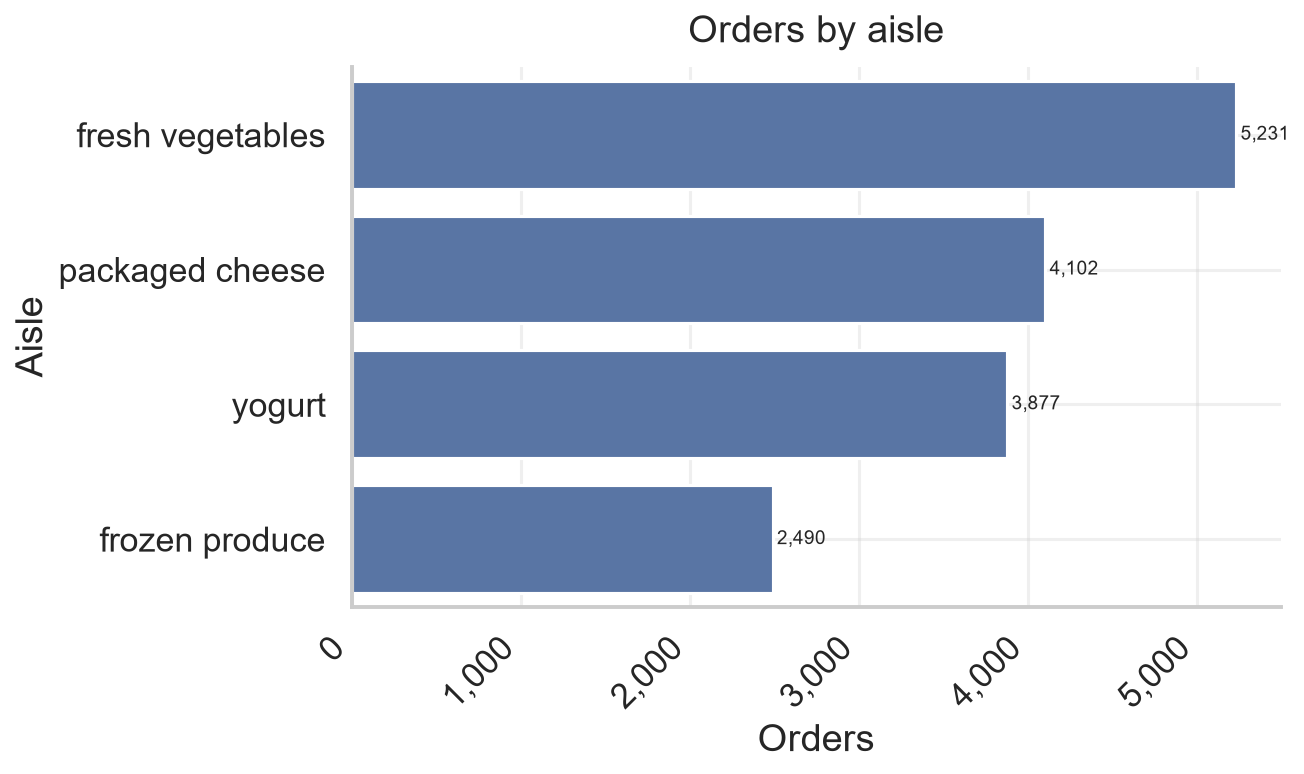

In [3]:
data = [
    {"orders": 5231, "aisle": "fresh vegetables"},
    {"orders": 4102, "aisle": "packaged cheese"},
    {"orders": 3877, "aisle": "yogurt"},
    {"orders": 2490, "aisle": "frozen produce"},
]
spec = {"chart_type": "horizontal_bar", "x_field": "orders", "y_field": "aisle",
        "title": "Orders by aisle", "x_label": "Orders", "y_label": "Aisle"}
validate_and_render(data, spec, HorizontalBarChartSpec)


## `grouped_bar`

Validated as GroupedBarChartSpec


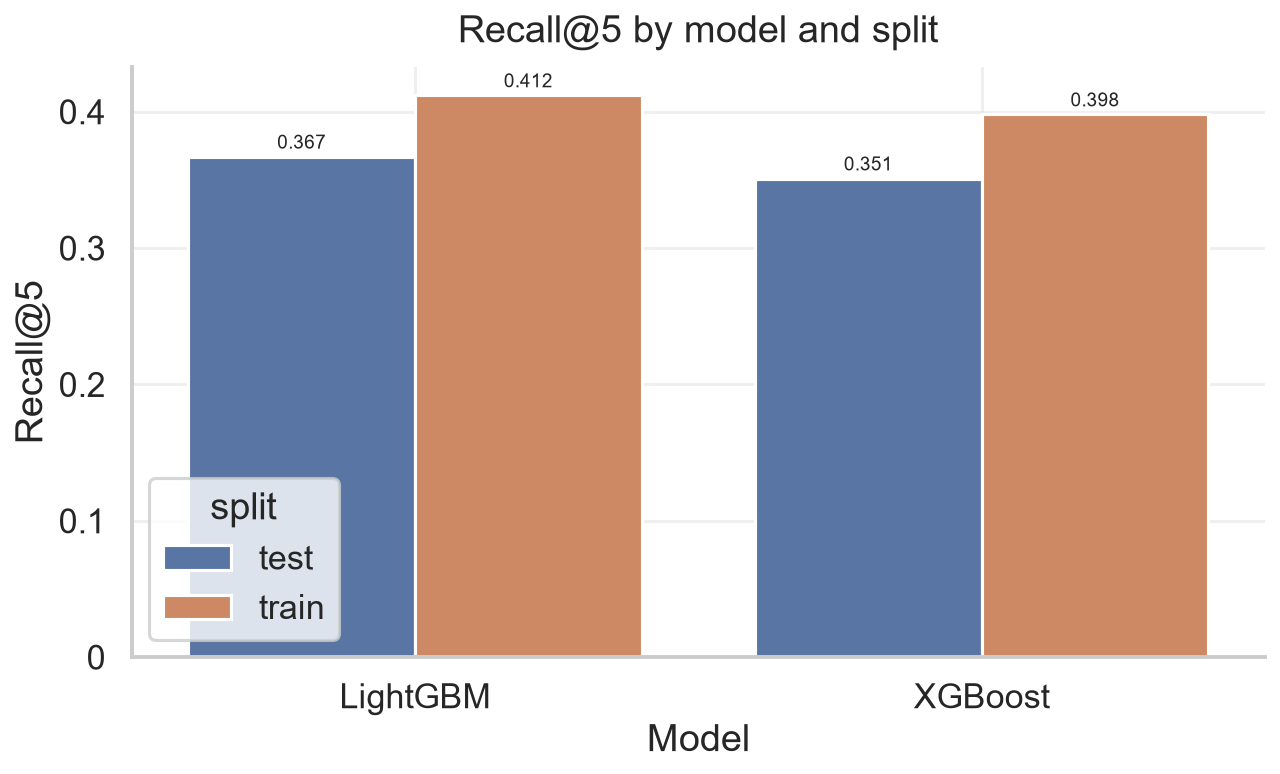

In [4]:
data = [
    {"model": "LightGBM", "recall": 0.367, "split": "test"},
    {"model": "LightGBM", "recall": 0.412, "split": "train"},
    {"model": "XGBoost", "recall": 0.351, "split": "test"},
    {"model": "XGBoost", "recall": 0.398, "split": "train"},
]
spec = {"chart_type": "grouped_bar", "x_field": "model", "y_field": "recall",
        "hue_field": "split", "title": "Recall@5 by model and split",
        "x_label": "Model", "y_label": "Recall@5"}
validate_and_render(data, spec, GroupedBarChartSpec)


## `stacked_horizontal_bar`

Validated as StackedHorizontalBarChartSpec


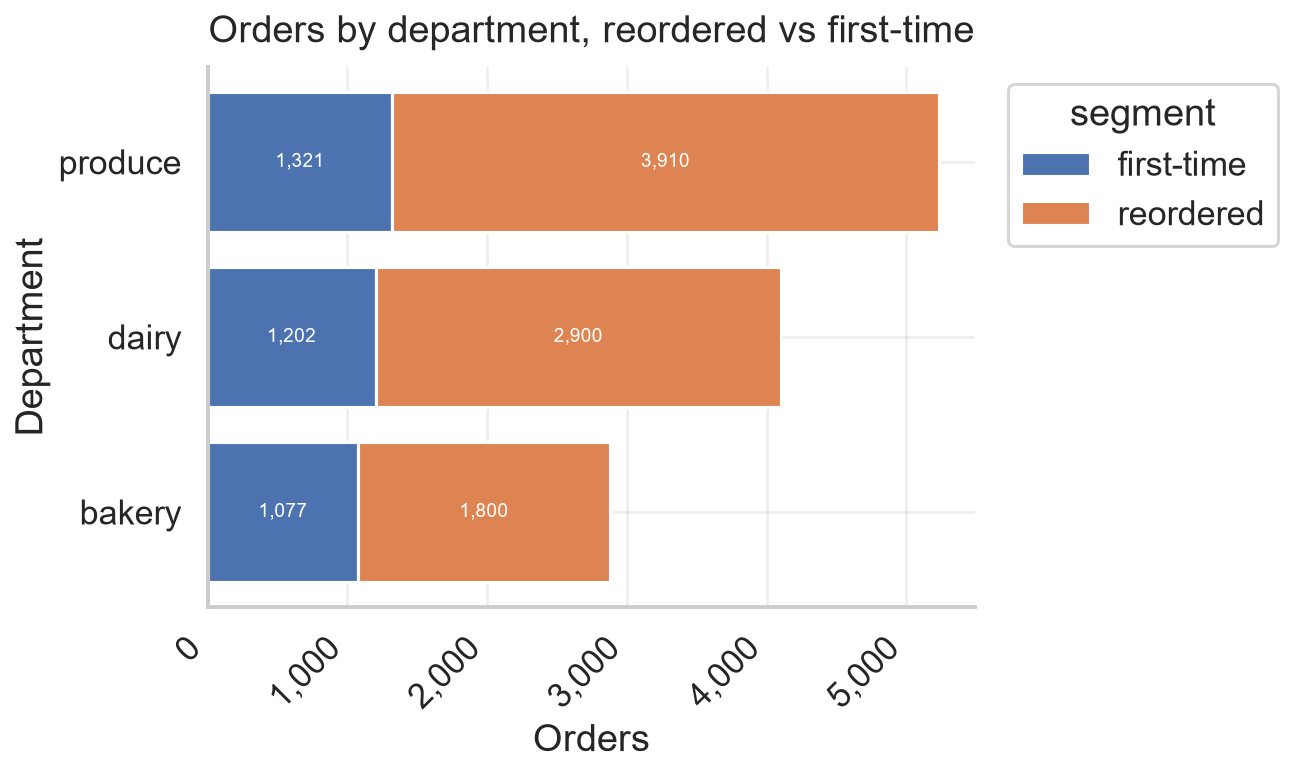

In [5]:
data = [
    {"department": "produce", "segment": "reordered", "orders": 3910},
    {"department": "produce", "segment": "first-time", "orders": 1321},
    {"department": "dairy", "segment": "reordered", "orders": 2900},
    {"department": "dairy", "segment": "first-time", "orders": 1202},
    {"department": "bakery", "segment": "reordered", "orders": 1800},
    {"department": "bakery", "segment": "first-time", "orders": 1077},
]
spec = {"chart_type": "stacked_horizontal_bar", "category_field": "department",
        "value_field": "orders", "segment_field": "segment",
        "title": "Orders by department, reordered vs first-time",
        "x_label": "Orders", "y_label": "Department"}
validate_and_render(data, spec, StackedHorizontalBarChartSpec)


## `line`

Validated as LineChartSpec


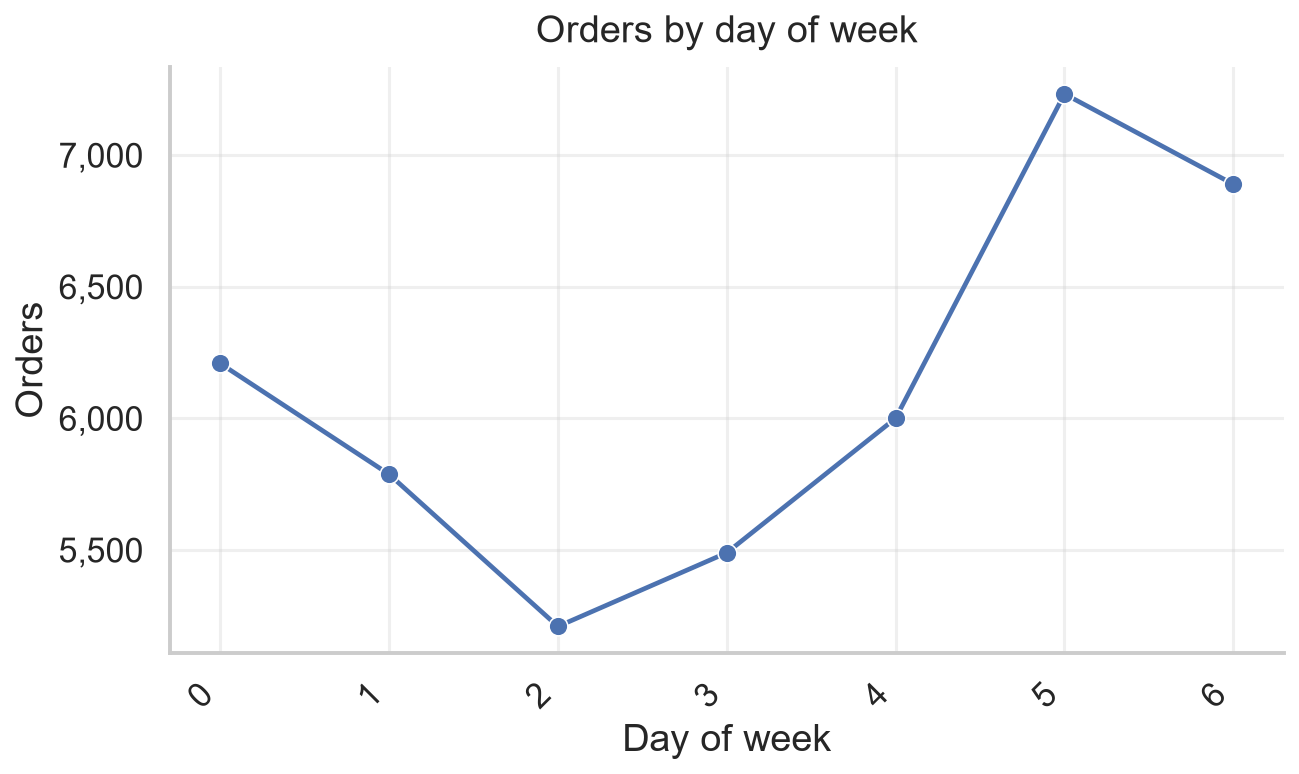

In [6]:
data = [
    {"order_dow": 0, "orders": 6209},
    {"order_dow": 1, "orders": 5788},
    {"order_dow": 2, "orders": 5210},
    {"order_dow": 3, "orders": 5490},
    {"order_dow": 4, "orders": 6001},
    {"order_dow": 5, "orders": 7233},
    {"order_dow": 6, "orders": 6890},
]
spec = {"chart_type": "line", "x_field": "order_dow", "y_field": "orders",
        "title": "Orders by day of week", "x_label": "Day of week",
        "y_label": "Orders"}
validate_and_render(data, spec, LineChartSpec)


## `histogram`

Validated as HistogramChartSpec


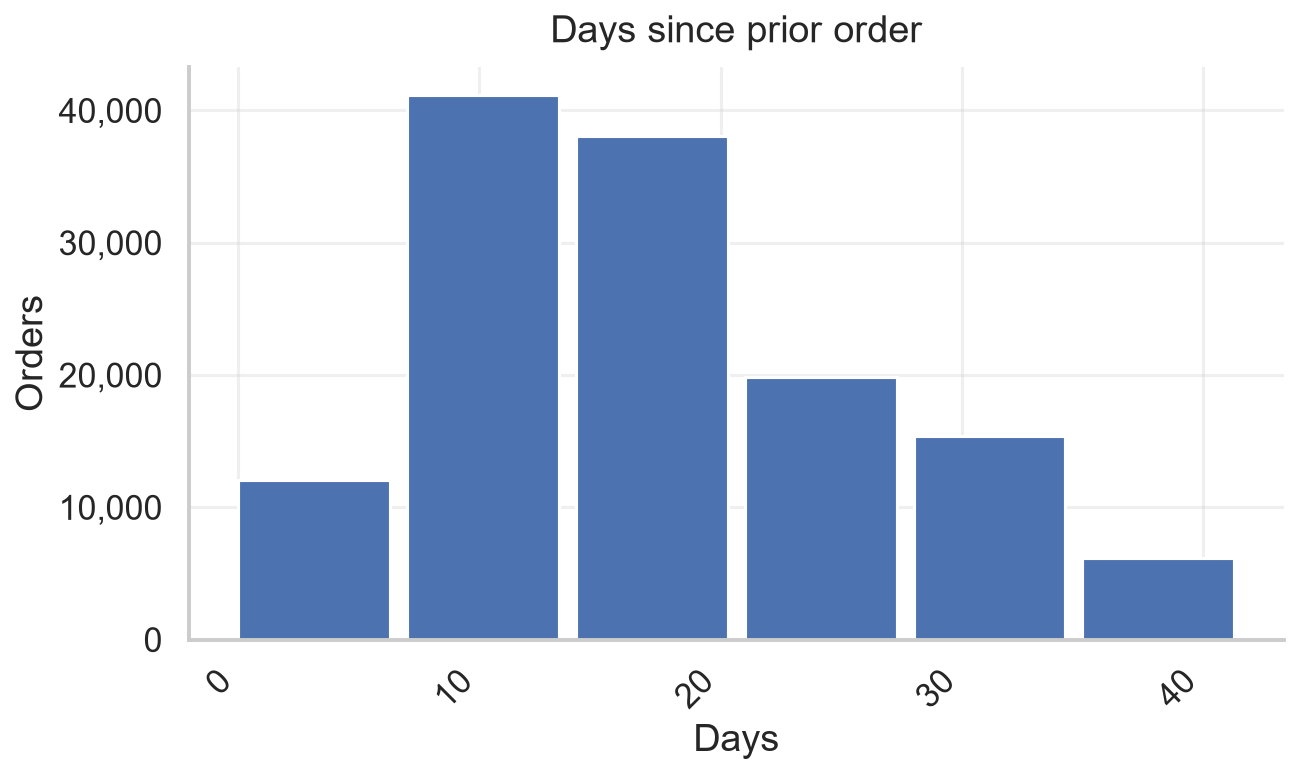

In [7]:
data = [
    {"bucket": 0, "n": 12034},
    {"bucket": 7, "n": 41203},
    {"bucket": 14, "n": 38102},
    {"bucket": 21, "n": 19887},
    {"bucket": 28, "n": 15421},
    {"bucket": 35, "n": 6209},
]
spec = {"chart_type": "histogram", "bucket_field": "bucket", "count_field": "n",
        "title": "Days since prior order", "x_label": "Days", "y_label": "Orders"}
validate_and_render(data, spec, HistogramChartSpec)


## `box`

Validated as BoxChartSpec


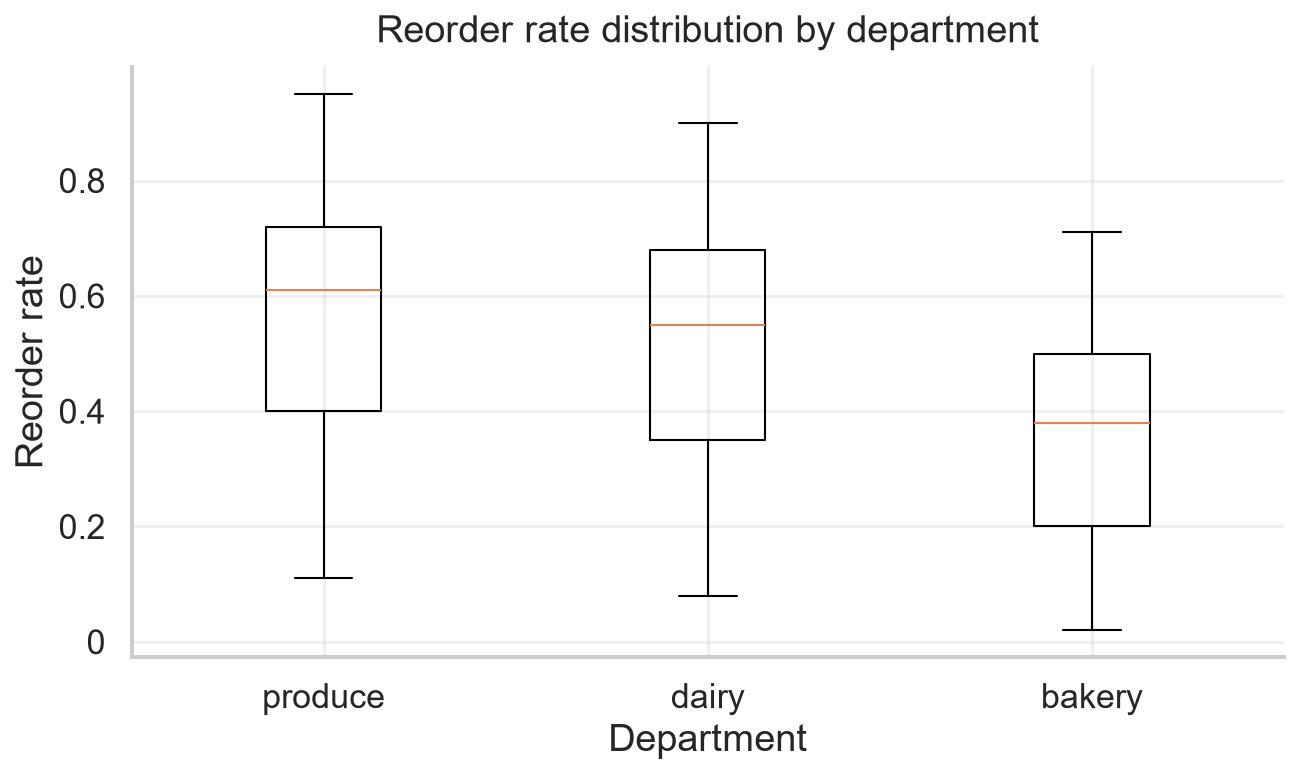

In [8]:
data = [
    {"department": "produce", "q1": 0.40, "med": 0.61, "q3": 0.72, "whislo": 0.11, "whishi": 0.95},
    {"department": "dairy", "q1": 0.35, "med": 0.55, "q3": 0.68, "whislo": 0.08, "whishi": 0.90},
    {"department": "bakery", "q1": 0.20, "med": 0.38, "q3": 0.50, "whislo": 0.02, "whishi": 0.71},
]
spec = {"chart_type": "box", "category_field": "department", "q1_field": "q1",
        "med_field": "med", "q3_field": "q3", "whislo_field": "whislo",
        "whishi_field": "whishi", "title": "Reorder rate distribution by department",
        "x_label": "Department", "y_label": "Reorder rate"}
validate_and_render(data, spec, BoxChartSpec)


## `heatmap`

Validated as HeatmapChartSpec


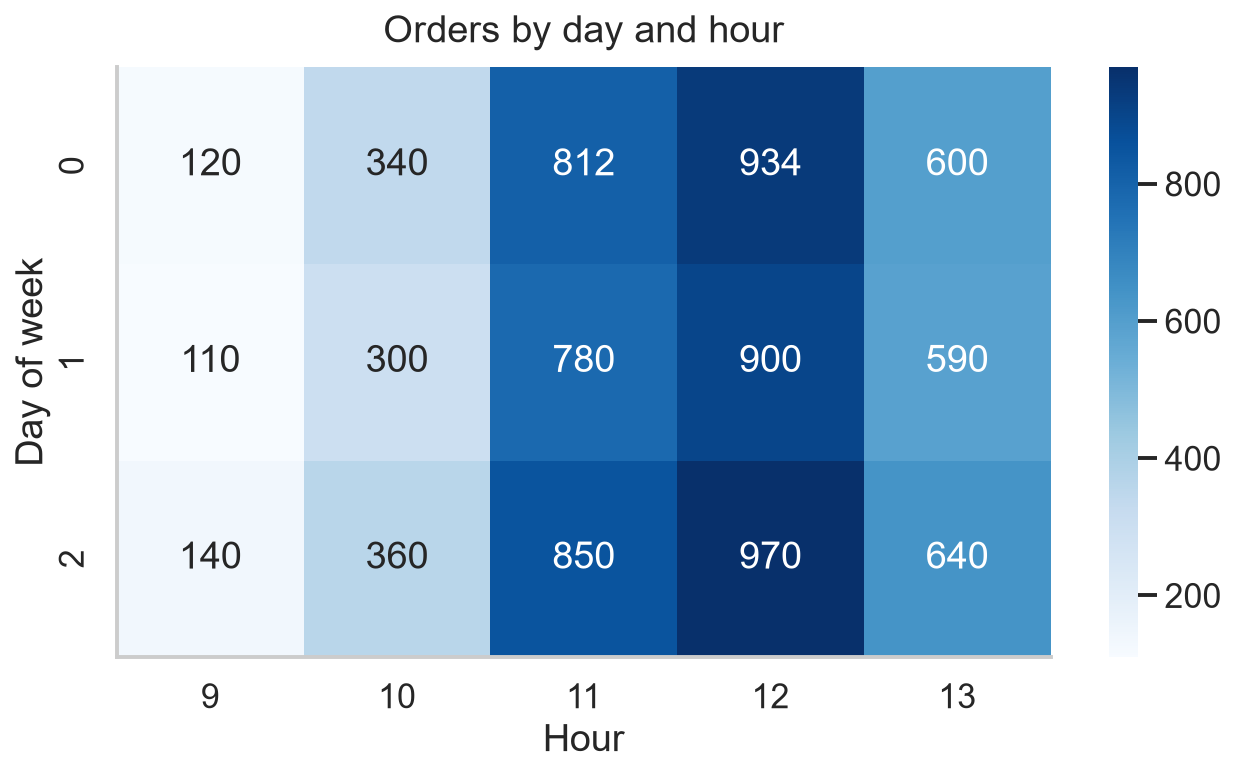

In [9]:
data = [
    {"order_dow": d, "order_hour": h, "orders": o}
    for d, hours in enumerate([
        [120, 340, 812, 934, 600],
        [110, 300, 780, 900, 590],
        [140, 360, 850, 970, 640],
    ])
    for h, o in zip([9, 10, 11, 12, 13], hours)
]
spec = {"chart_type": "heatmap", "x_field": "order_hour", "y_field": "order_dow",
        "value_field": "orders", "title": "Orders by day and hour",
        "x_label": "Hour", "y_label": "Day of week"}
validate_and_render(data, spec, HeatmapChartSpec)


## `concentration`

Validated as ConcentrationChartSpec


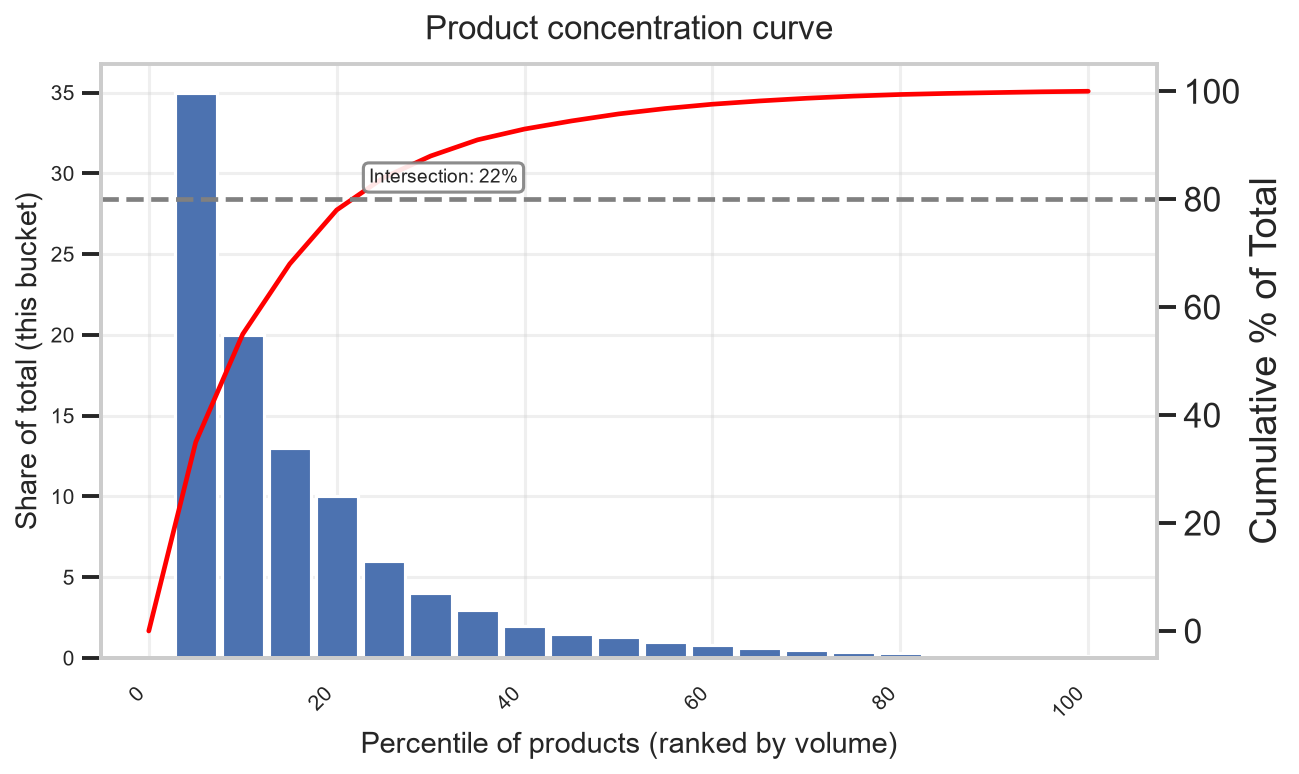

In [2]:
data = [
    {"pct": 5, "cum_pct": 35}, {"pct": 10, "cum_pct": 55},
    {"pct": 15, "cum_pct": 68}, {"pct": 20, "cum_pct": 78},
    {"pct": 25, "cum_pct": 84}, {"pct": 30, "cum_pct": 88},
    {"pct": 35, "cum_pct": 91}, {"pct": 40, "cum_pct": 93},
    {"pct": 45, "cum_pct": 94.5}, {"pct": 50, "cum_pct": 95.8},
    {"pct": 55, "cum_pct": 96.8}, {"pct": 60, "cum_pct": 97.6},
    {"pct": 65, "cum_pct": 98.2}, {"pct": 70, "cum_pct": 98.7},
    {"pct": 75, "cum_pct": 99.1}, {"pct": 80, "cum_pct": 99.4},
    {"pct": 85, "cum_pct": 99.6}, {"pct": 90, "cum_pct": 99.75},
    {"pct": 95, "cum_pct": 99.9}, {"pct": 100, "cum_pct": 100.0},
]
spec = {"chart_type": "concentration", "percentile_field": "pct",
        "cumulative_pct_field": "cum_pct", "title": "Product concentration curve",
        "x_label": "Percentile of products (ranked by volume)",
        "y_label": "Share of total (this bucket)"}
validate_and_render(data, spec, ConcentrationChartSpec)


## `pareto`

Validated as ParetoChartSpec


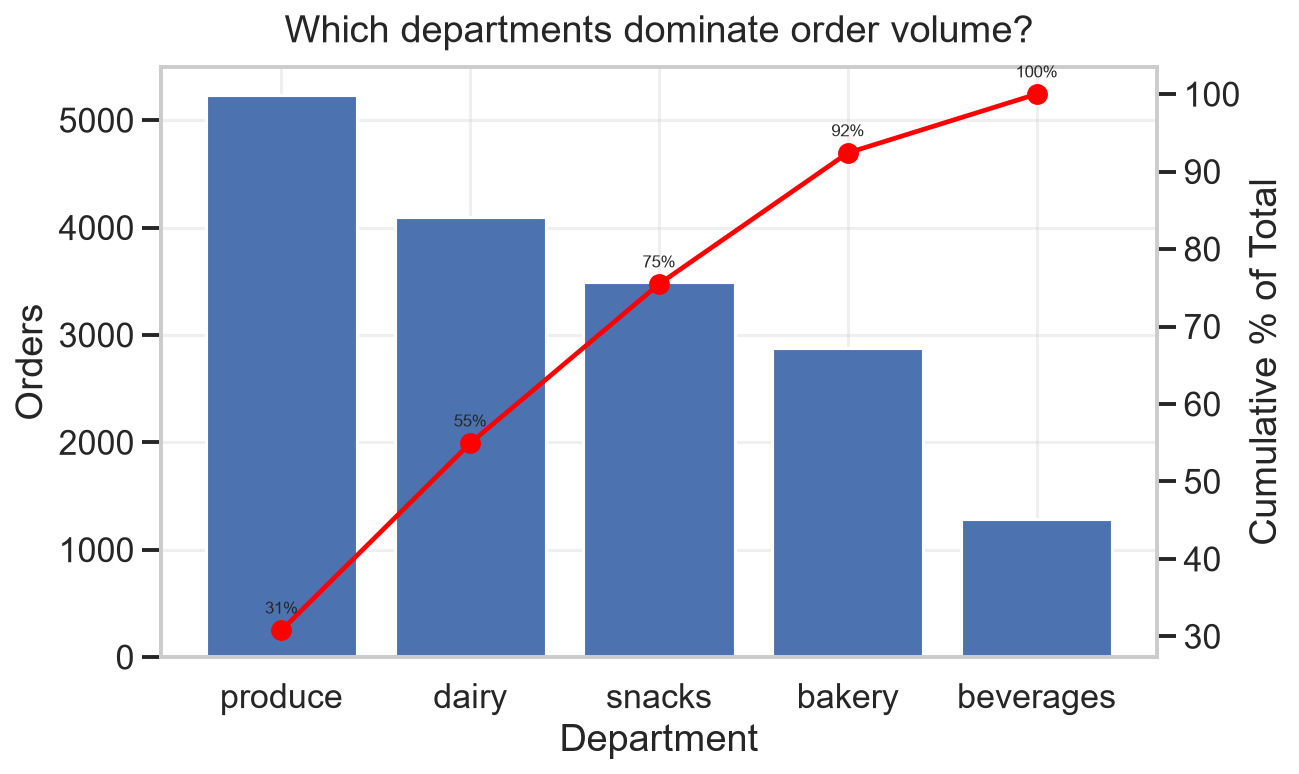

In [11]:
data = [
    {"department": "produce", "orders": 5231},
    {"department": "dairy", "orders": 4102},
    {"department": "snacks", "orders": 3490},
    {"department": "bakery", "orders": 2877},
    {"department": "beverages", "orders": 1290},
]
spec = {"chart_type": "pareto", "category_field": "department", "value_field": "orders",
        "title": "Which departments dominate order volume?",
        "x_label": "Department", "y_label": "Orders"}
validate_and_render(data, spec, ParetoChartSpec)
